Preparing FGVCAircraft Dataset and Augmentations...


100%|██████████| 2.75G/2.75G [00:31<00:00, 86.5MB/s]


Loading Teacher (CLIP)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


--- Starting Training ---
 --> Best checkpoint saved with 1.14% Accuracy
Epoch 1/40: Train Acc 1.27% | Val Acc 1.14% | LR: 0.000200
 --> Best checkpoint saved with 38.94% Accuracy
Epoch 2/40: Train Acc 28.18% | Val Acc 38.94% | LR: 0.000199
 --> Best checkpoint saved with 53.11% Accuracy
Epoch 3/40: Train Acc 57.67% | Val Acc 53.11% | LR: 0.000197
 --> Best checkpoint saved with 68.02% Accuracy
Epoch 4/40: Train Acc 72.84% | Val Acc 68.02% | LR: 0.000195
 --> Best checkpoint saved with 68.50% Accuracy
Epoch 5/40: Train Acc 77.95% | Val Acc 68.50% | LR: 0.000192
Epoch 6/40: Train Acc 85.11% | Val Acc 66.52% | LR: 0.000189
 --> Best checkpoint saved with 72.43% Accuracy
Epoch 7/40: Train Acc 89.35% | Val Acc 72.43% | LR: 0.000185
Epoch 8/40: Train Acc 92.32% | Val Acc 72.40% | LR: 0.000181
 --> Best checkpoint saved with 74.59% Accuracy
Epoch 9/40: Train Acc 95.17% | Val Acc 74.59% | LR: 0.000176
Epoch 10/40: Train Acc 96.30% | Val Acc 73.42% | LR: 0.000171
 --> Best checkpoint saved wi

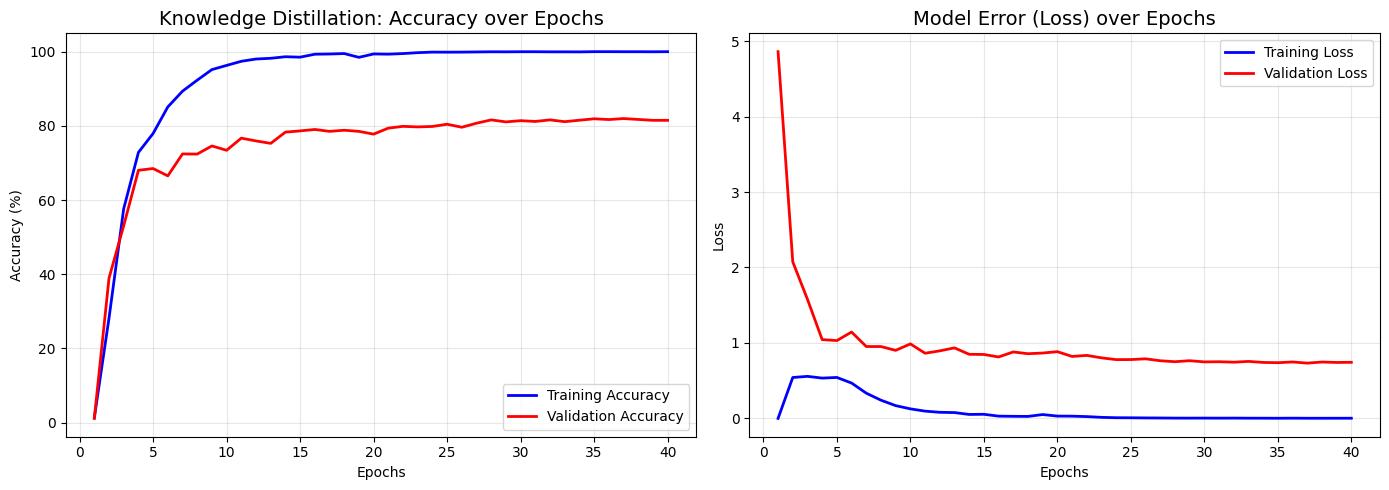


Calculating Advanced Metrics on Full Test Set...
--- Full Test Set Metrics ---
Precision : 82.25%
Recall    : 81.49%
F1 Score  : 81.53%

Generating Confusion Matrix (This might take a minute)...


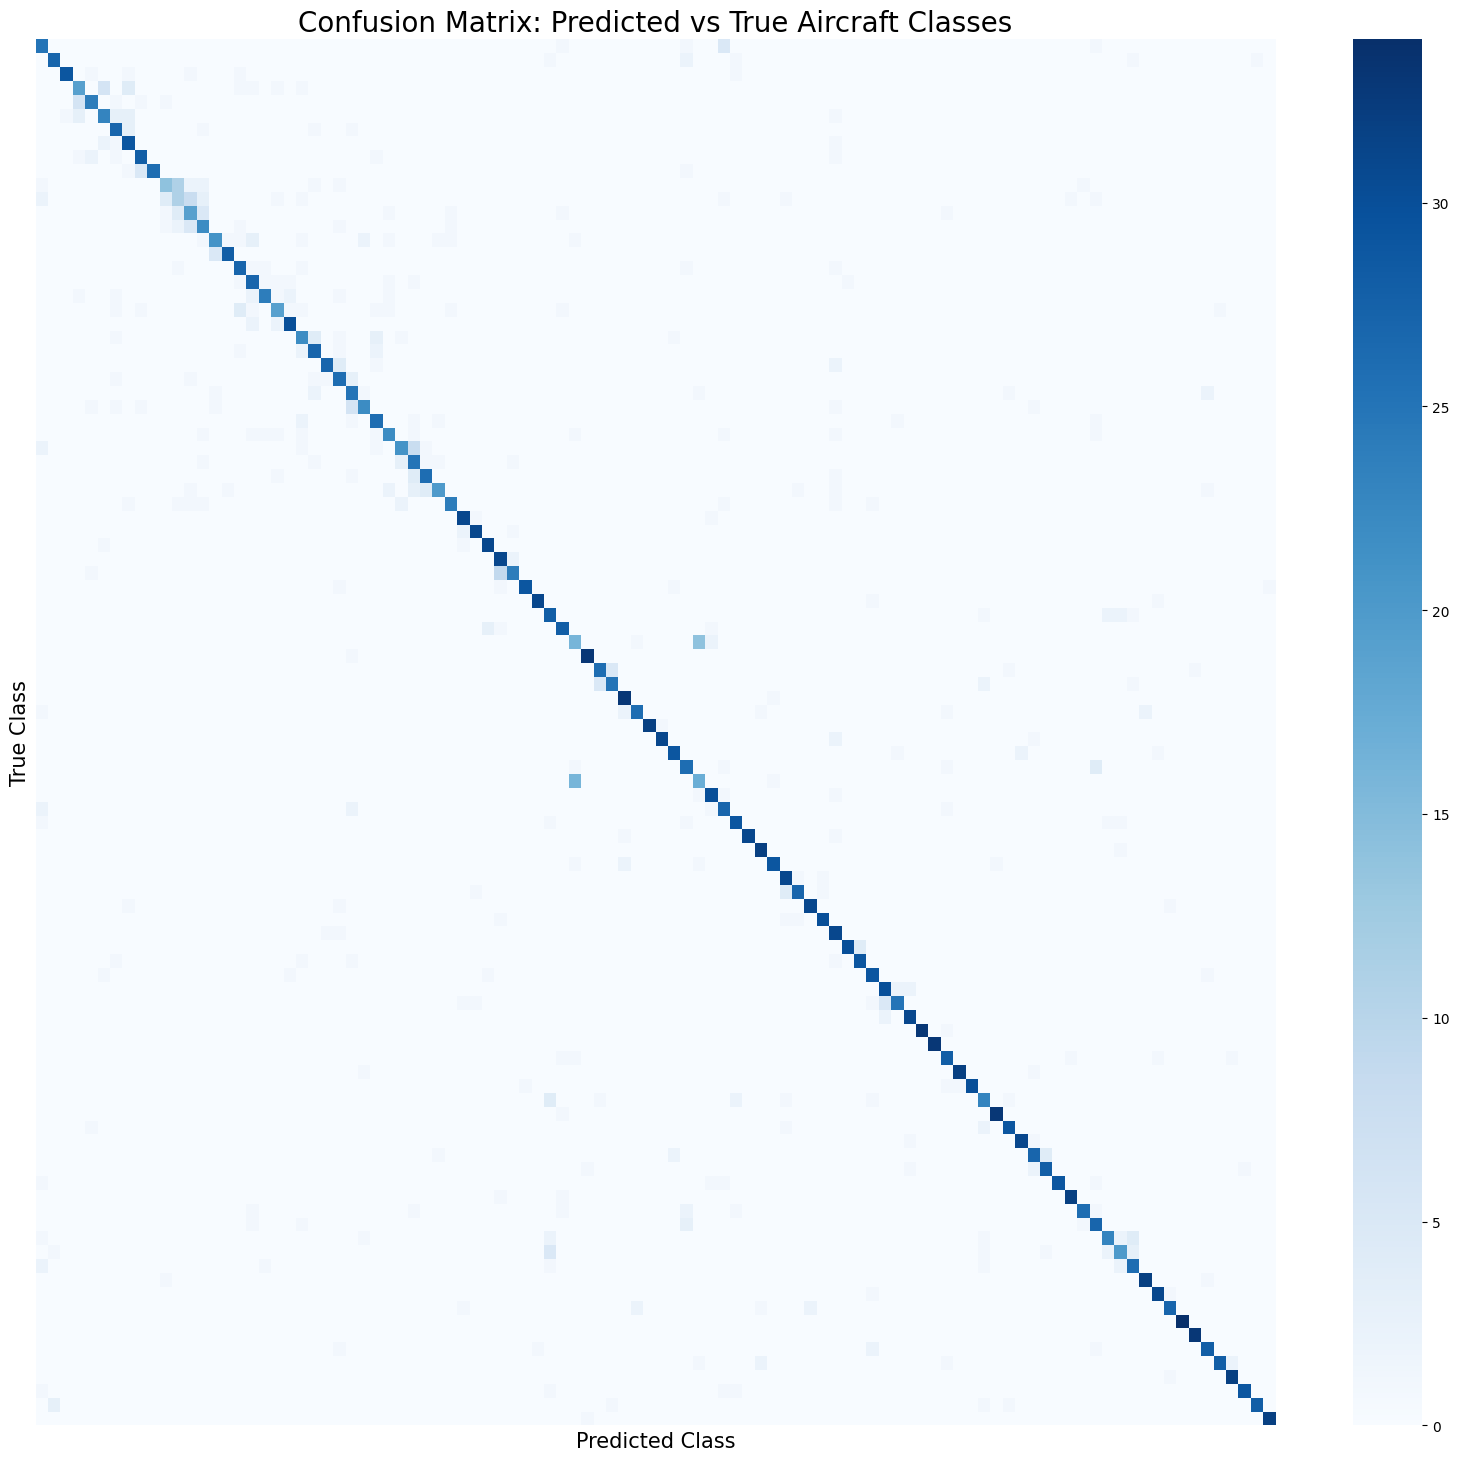


Initializing a Standard Baseline ResNet-34 for comparison...
Loading Student (ResNet-34)...

      FINAL SCORE on 25 Images      
Distilled Model: 19/25 (76.0%)
Standard Model : 0/25 (0.0%)
Improvement    : +76.0%



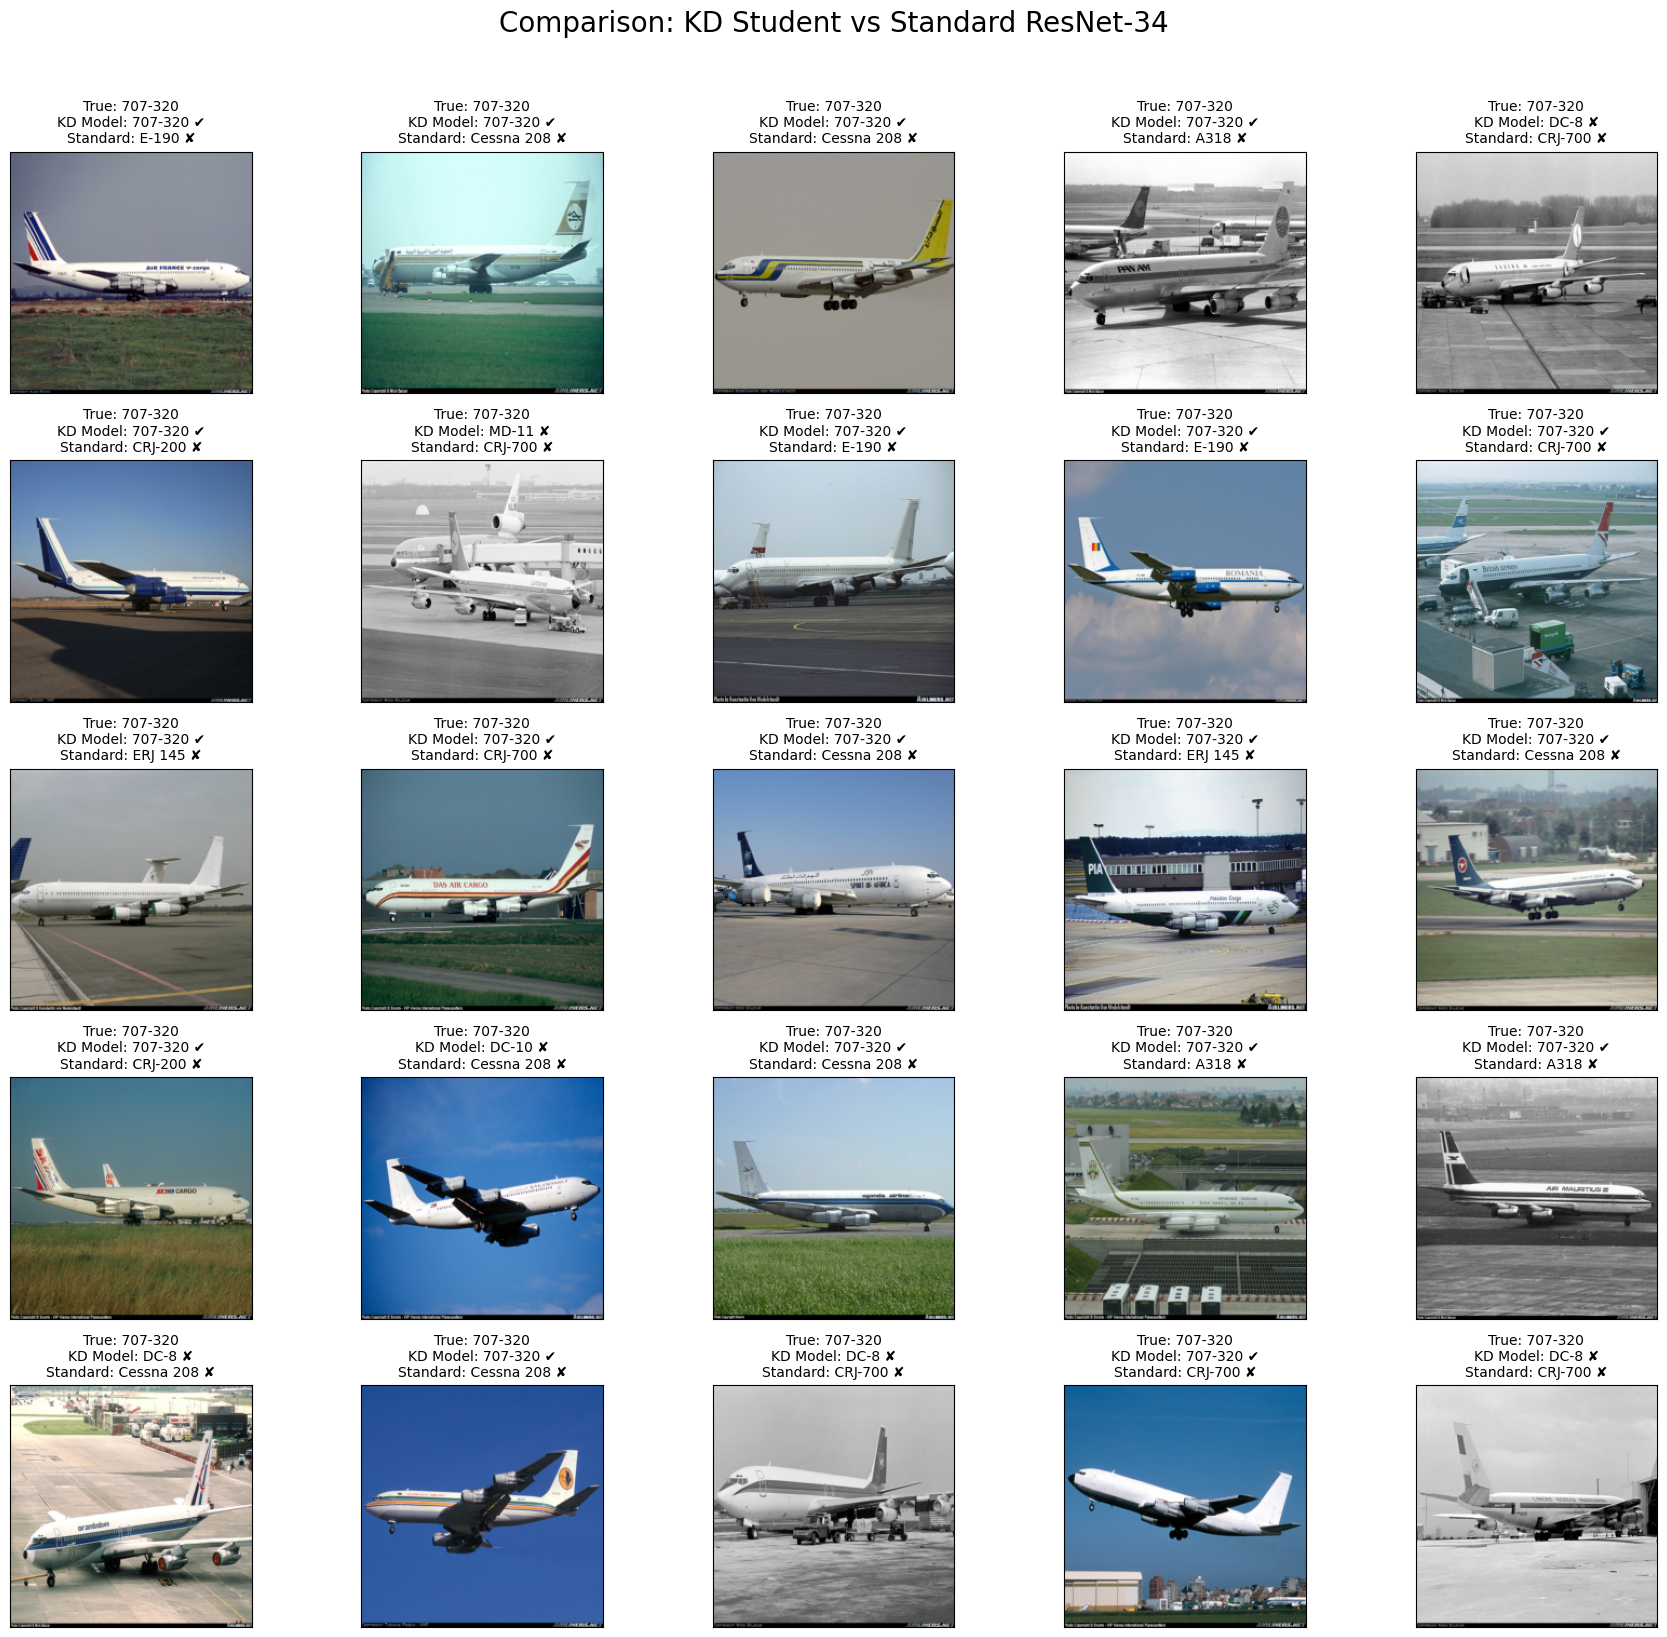

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import numpy as np
from PIL import Image


    # Define variables directly
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
EPOCHS = 40
LR = 2e-4
TEMPERATURE = 0.07
SAVE_PATH = "vl2lite_fgvc_resnet34_checkpoint.pt"

# ==========================================
# BLOCK 1: DATA PREPARATION (FGVCAircraft)
# ==========================================

def get_dataloaders(batch_size):
    """Returns train and test dataloaders for the FGVCAircraft dataset."""
    print("Preparing FGVCAircraft Dataset and Augmentations...")

    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.FGVCAircraft(root='./data', split='trainval', download=True, transform=train_transform)
    test_dataset = datasets.FGVCAircraft(root='./data', split='test', download=True, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, test_loader, train_dataset.classes

# ==========================================
# BLOCK 2: MODELS DEFINITIONS (ResNet-34)
# ==========================================

def get_teacher_model(device):
    """Loads and freezes the CLIP Teacher model."""
    print("Loading Teacher (CLIP)...")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model

def get_student_model(num_classes, device):
    """Loads the ResNet-34 Student model."""
    print("Loading Student (ResNet-34)...")
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def get_connector(input_dim=512, output_dim=512, device='cuda'):
    """
    Creates the projection connector.
    Note: ResNet-34 outputs 512 features (same as ResNet-18).
    """
    connector = nn.Sequential(
        nn.Linear(input_dim, input_dim // 2),
        nn.ReLU(),
        nn.Linear(input_dim // 2, output_dim)
    ).to(device)
    return connector

# ==========================================
# BLOCK 3: FEATURE EXTRACTION & FORWARD PASS
# ==========================================

def extract_teacher_features(teacher_model, images):
    """Safely extracts image features from CLIP."""
    with torch.no_grad():
        if hasattr(teacher_model, "get_image_features"):
            features = teacher_model.get_image_features(images)
        else:
            vision_outputs = teacher_model.vision_model(images)
            pooled_output = vision_outputs.pooler_output if hasattr(vision_outputs, 'pooler_output') else vision_outputs[1]
            features = teacher_model.visual_projection(pooled_output)

        if not isinstance(features, torch.Tensor):
            features = features.pooler_output if hasattr(features, 'pooler_output') else features[0]

        return features / features.norm(p=2, dim=-1, keepdim=True)

def get_text_anchors(class_names, device):
    """Extracts fixed text anchor representations."""
    print("Generating Text Anchors...")
    teacher = get_teacher_model(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    prompts = [f"a photo of a {c}" for c in class_names]
    inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        if hasattr(teacher, "get_text_features"):
            txt_feats = teacher.get_text_features(**inputs)
        else:
            txt_out = teacher.text_model(**inputs)
            pooled_output = txt_out.pooler_output if hasattr(txt_out, 'pooler_output') else txt_out[1]
            txt_feats = teacher.text_projection(pooled_output)

        if not isinstance(txt_feats, torch.Tensor):
            txt_feats = txt_feats.pooler_output if hasattr(txt_feats, 'pooler_output') else txt_feats[0]

        txt_feats = txt_feats / txt_feats.norm(p=2, dim=-1, keepdim=True)

    del teacher
    torch.cuda.empty_cache()
    return txt_feats

def forward_student(student_model, connector_model, images):
    """Performs the forward pass manually to extract raw features."""
    x = student_model.conv1(images)
    x = student_model.bn1(x)
    x = student_model.relu(x)
    x = student_model.maxpool(x)
    x = student_model.layer1(x)
    x = student_model.layer2(x)
    x = student_model.layer3(x)
    x = student_model.layer4(x)
    x = student_model.avgpool(x)
    feat_raw = torch.flatten(x, 1)

    logits = student_model.fc(feat_raw)
    feat_proj = connector_model(feat_raw)
    feat_proj = feat_proj / feat_proj.norm(p=2, dim=-1, keepdim=True)

    return logits, feat_proj

# ==========================================
# BLOCK 4: LOSS & TRAINING FUNCTIONS (OFFICIAL MATH)
# ==========================================

def calculate_kd_loss(student_logits, student_projected, teacher_features, text_anchors, labels, current_epoch, total_epochs, temperature=0.07):
    """
    The mathematically accurate VL2Lite Loss Function.
    Implements KL-Divergence on similarity logits and the aggressive 12.5% weighting schedule.
    """
    ramp_factor = current_epoch / max(1, (total_epochs * 0.125))
    w_task = min(max(ramp_factor, 0.0), 1.0)
    w_distill = 1.0 - w_task

    loss_task = F.cross_entropy(student_logits, labels)
    loss_visual = F.mse_loss(student_projected, teacher_features)

    logit_scale = 1.0 / temperature

    student_sim_logits = logit_scale * torch.matmul(student_projected, text_anchors.t())
    teacher_sim_logits = logit_scale * torch.matmul(teacher_features, text_anchors.t())

    log_student_probs = F.log_softmax(student_sim_logits, dim=-1)
    teacher_probs = F.softmax(teacher_sim_logits, dim=-1)

    kl_criterion = nn.KLDivLoss(reduction='batchmean')
    loss_text = kl_criterion(log_student_probs, teacher_probs) * (temperature ** 2)

    final_loss = (w_task * loss_task) + (w_distill * ((loss_visual + loss_text) / 2.0))
    return final_loss

def evaluate_model(student_model, test_loader, device):
    """Evaluates the student model."""
    student_model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = student_model(imgs)
            l = F.cross_entropy(out, lbls)
            v_loss += l.item()
            _, pred = torch.max(out, 1)
            v_correct += (pred == lbls).sum().item()
            v_total += lbls.size(0)

    val_acc = 100 * v_correct / v_total
    avg_v_loss = v_loss / len(test_loader)
    return val_acc, avg_v_loss

def train_model(train_loader, test_loader, class_names, epochs, lr, temperature, batch_size, device, save_path):
    """Main training loop directly accepting parameters."""
    teacher = get_teacher_model(device)
    student = get_student_model(len(class_names), device)
    connector = get_connector(input_dim=512, output_dim=512, device=device) # input_dim=512 for ResNet-34
    text_anchors = get_text_anchors(class_names, device)

    optimizer = optim.AdamW(list(student.parameters()) + list(connector.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda') if device == 'cuda' else None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0

    print("\n--- Starting Training ---")
    for epoch in range(epochs):
        student.train()
        connector.train()
        t_loss, t_correct, t_total = 0, 0, 0

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
                t_feats = extract_teacher_features(teacher, imgs)
                logits, feat_proj = forward_student(student, connector, imgs)

                loss = calculate_kd_loss(
                    logits, feat_proj, t_feats, text_anchors, lbls,
                    current_epoch=epoch,
                    total_epochs=epochs,
                    temperature=temperature
                )

            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            t_loss += loss.item()
            _, pred = torch.max(logits, 1)
            t_correct += (pred == lbls).sum().item()
            t_total += lbls.size(0)

        scheduler.step()

        train_acc = 100 * t_correct / t_total
        avg_t_loss = t_loss / len(train_loader)
        val_acc, avg_v_loss = evaluate_model(student, test_loader, device)

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

            checkpoint = {
                'epoch': best_epoch,
                'model_state_dict': student.state_dict(),
                'connector_state_dict': connector.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'best_acc': best_val_acc,
                'best_epoch': best_epoch,
                'config': {
                    'batch_size': batch_size,
                    'learning_rate': lr,
                    'num_classes': len(class_names),
                    'device': device
                }
            }
            torch.save(checkpoint, save_path)
            print(f" --> Best checkpoint saved with {val_acc:.2f}% Accuracy")

        print(f"Epoch {epoch+1}/{epochs}: Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | LR: {scheduler.get_last_lr()[0]:.6f}")

    return history, student

# ==========================================
# BLOCK 5: VISUALIZATION & EVALUATION
# ==========================================

def unnormalize_image(img_tensor):
    """Reverts the ImageNet normalization so images can be plotted correctly."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def plot_results(history):
    """Plots the Training and Validation Accuracy/Loss curves side-by-side."""
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    plt.title('Knowledge Distillation: Accuracy over Epochs', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    plt.title('Model Error (Loss) over Epochs', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_func(student_model, test_loader, class_names, device):
    """Generates a heatmap Confusion Matrix for the entire test dataset."""
    print("Generating Confusion Matrix (This might take a minute)...")
    student_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            outputs = student_model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
    plt.title('Confusion Matrix: Predicted vs True Aircraft Classes', fontsize=20)
    plt.xlabel('Predicted Class', fontsize=15)
    plt.ylabel('True Class', fontsize=15)
    plt.show()

def print_advanced_metrics(student_model, test_loader, device):
    """Calculates Precision, Recall, and F1 Score over the entire test dataset."""
    print("\nCalculating Advanced Metrics on Full Test Set...")
    student_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            outputs = student_model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    print(f"--- Full Test Set Metrics ---")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1 Score  : {f1 * 100:.2f}%\n")

def compare_models_25_images(student_model, test_loader, class_names, device):
    """Compares Baseline ResNet-34 against the KD Student model on 25 images."""
    print("\nInitializing a Standard Baseline ResNet-34 for comparison...")
    baseline_model = get_student_model(len(class_names), device)
    baseline_model.eval()
    student_model.eval()

    imgs, labels = next(iter(test_loader))
    imgs, labels = imgs[:25], labels[:25]
    imgs_to_device = imgs.to(device)
    labels_to_device = labels.to(device)

    with torch.no_grad():
        student_out = student_model(imgs_to_device)
        _, student_preds = torch.max(student_out, 1)

        baseline_out = baseline_model(imgs_to_device)
        _, baseline_preds = torch.max(baseline_out, 1)

    s_score = (student_preds == labels_to_device).sum().item()
    b_score = (baseline_preds == labels_to_device).sum().item()

    print(f"\n====================================")
    print(f"      FINAL SCORE on 25 Images      ")
    print(f"====================================")
    print(f"Distilled Model: {s_score}/25 ({(s_score/25)*100:.1f}%)")
    print(f"Standard Model : {b_score}/25 ({(b_score/25)*100:.1f}%)")

    improvement = ((s_score - b_score) / 25) * 100
    if improvement >= 0:
        print(f"Improvement    : +{improvement:.1f}%")
    else:
        print(f"Improvement    : {improvement:.1f}%")
    print(f"====================================\n")

    fig = plt.figure(figsize=(18, 16))
    fig.suptitle('Comparison: KD Student vs Standard ResNet-34', fontsize=20, y=1.02)

    for i in range(25):
        ax = fig.add_subplot(5, 5, i+1, xticks=[], yticks=[])
        img_np = unnormalize_image(imgs[i])
        ax.imshow(img_np)

        true_name = class_names[labels[i]][:15]
        s_pred = class_names[student_preds[i]][:15]
        b_pred = class_names[baseline_preds[i]][:15]

        s_mark = "✔" if student_preds[i] == labels[i] else "✘"
        b_mark = "✔" if baseline_preds[i] == labels[i] else "✘"

        ax.set_title(f"True: {true_name}\nKD Model: {s_pred} {s_mark}\nStandard: {b_pred} {b_mark}",
                     fontsize=10,
                     color='black',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

    plt.tight_layout()
    plt.show()

# ==========================================
# BLOCK 6: MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Load Data
    train_loader, test_loader, class_names = get_dataloaders(BATCH_SIZE)

    # Train directly
    history, trained_student = train_model(
        train_loader=train_loader,
        test_loader=test_loader,
        class_names=class_names,
        epochs=EPOCHS,
        lr=LR,
        temperature=TEMPERATURE,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        save_path=SAVE_PATH
    )

    print("\n--- Generating Evaluation Metrics ---")
    plot_results(history)
    print_advanced_metrics(trained_student, test_loader, DEVICE)
    plot_confusion_matrix_func(trained_student, test_loader, class_names, DEVICE)
    compare_models_25_images(trained_student, test_loader, class_names, DEVICE)